# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

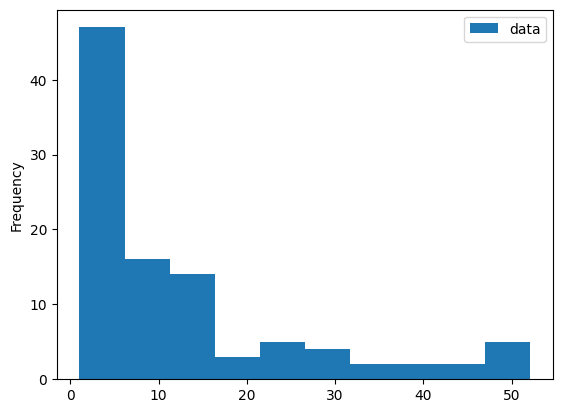

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

For pros this graph shows well the distribution of the drug prices and allows for a quick comparison of the fruquency of each price. For cons, this graph is not well labeled. There is no main title, the legend is unclear, and is no x-axis title. 

<Axes: >

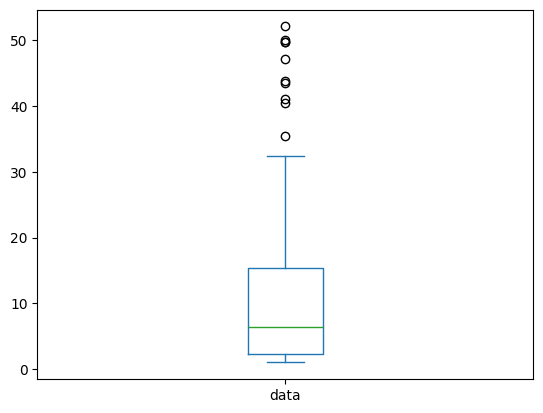

In [3]:
df.plot.box()

For pros, this box plot gives a clearer view of the distribution since the quartiles are marked and outliers are separately indicated. For cons, similar to the previous graph, there is a lack of labeling and no title. There also seems to be a lot of white space betweent the actual plot and the y-axis which makes it harder to identify the values.  

I would choose the box plot for this senario because I imagine the administrator would be interested in knowing the details such as the minimum, maximum, median, and the quartiles. I believe the histogram would be better suited if the administator wanted a brief overview of the distribution. I would definitely decrease the amount of white space by decreasing the width and bringing the box plot closer to the y-axis for better comparison. I would also add labels and a main title to clarify what the graph represents. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [12]:
marketing_df = pd.read_csv('marketing_and_product_performance.csv')


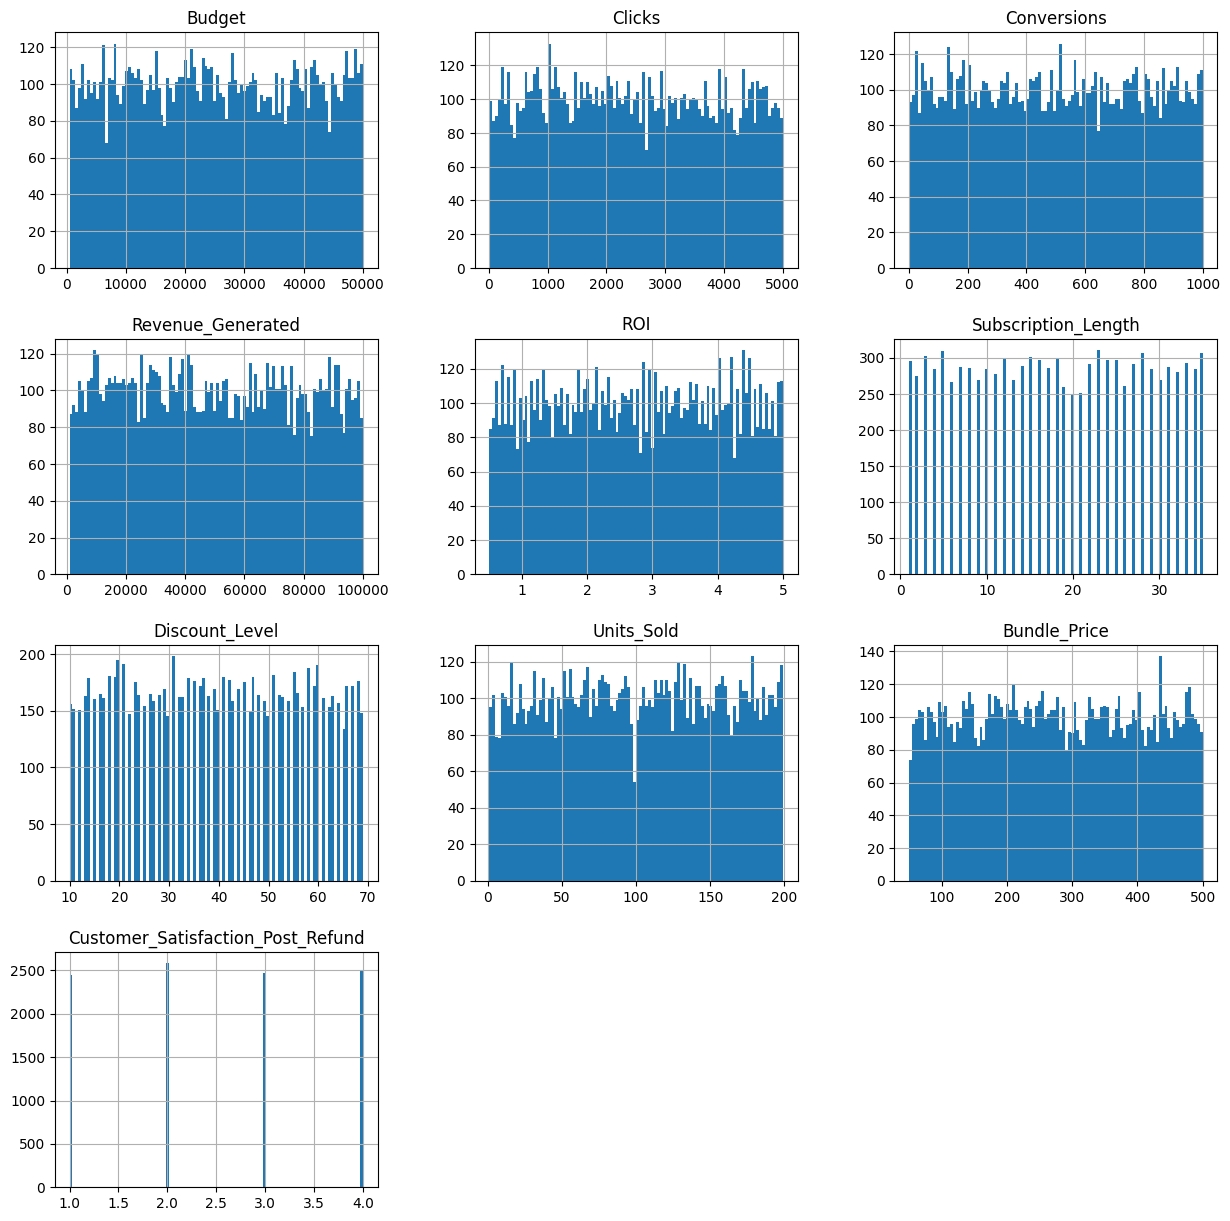

Column: Budget
Max: 49999.63
Min: 500.44
Mean: 25263.607524000003
Column: Clicks
Max: 4999
Min: 10
Mean: 2481.9036
Column: Conversions
Max: 999
Min: 1
Mean: 498.9787
Column: Revenue_Generated
Max: 99999.47
Min: 1002.08
Mean: 50038.62757899999
Column: ROI
Max: 5.0
Min: 0.5
Mean: 2.756365
Column: Subscription_Length
Max: 35
Min: 1
Mean: 18.0165
Column: Discount_Level
Max: 69
Min: 10
Mean: 39.421
Column: Units_Sold
Max: 199
Min: 1
Mean: 100.6896
Column: Bundle_Price
Max: 499.97
Min: 50.01
Mean: 275.198346
Column: Customer_Satisfaction_Post_Refund
Max: 4
Min: 1
Mean: 2.5009


In [34]:
marketing_df.hist(figsize=(15, 15), bins=100)
plt.show()

numeric_cols = marketing_df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    print(f"Column: {col}")
    print(f"Max: {marketing_df[col].max()}")
    print(f"Min: {marketing_df[col].min()}")
    print(f"Mean: {marketing_df[col].mean()}")


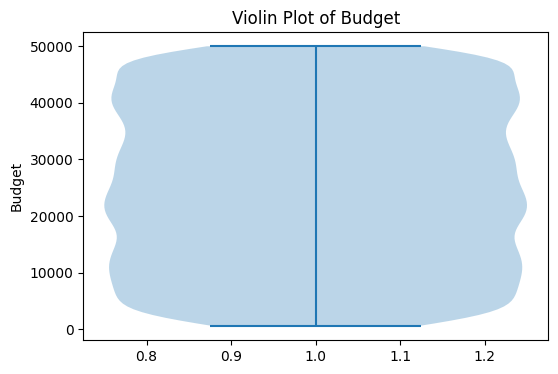

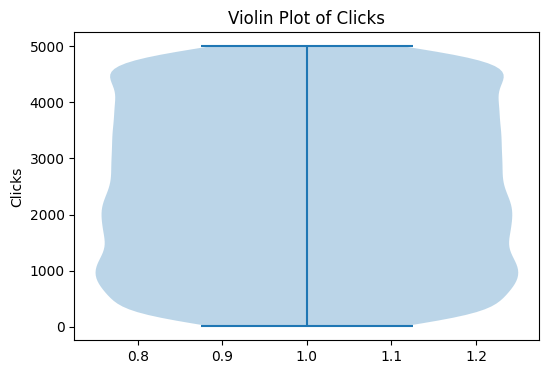

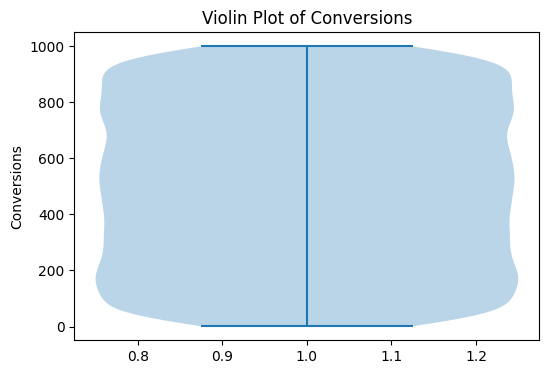

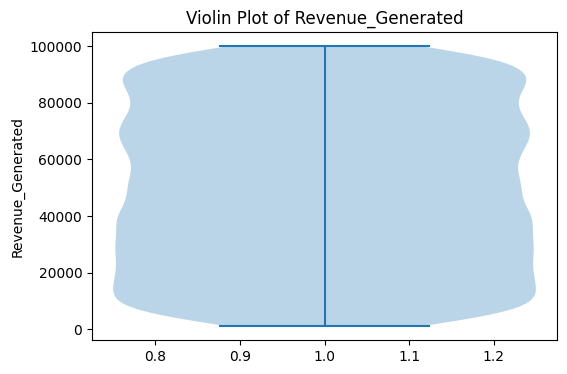

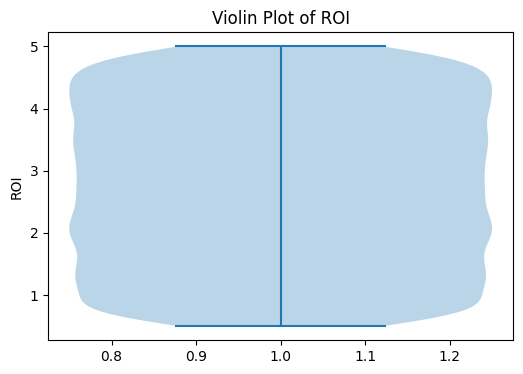

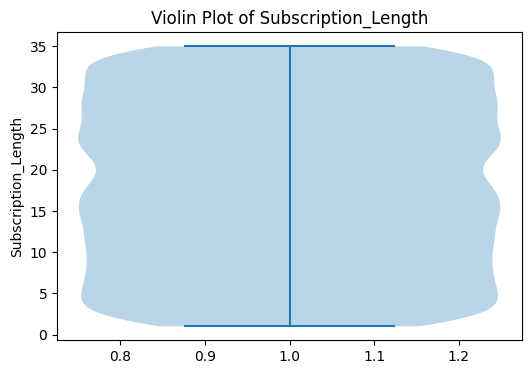

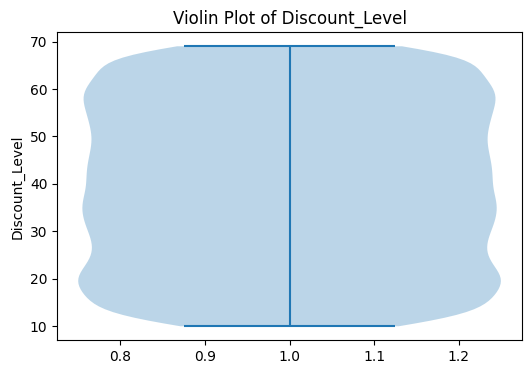

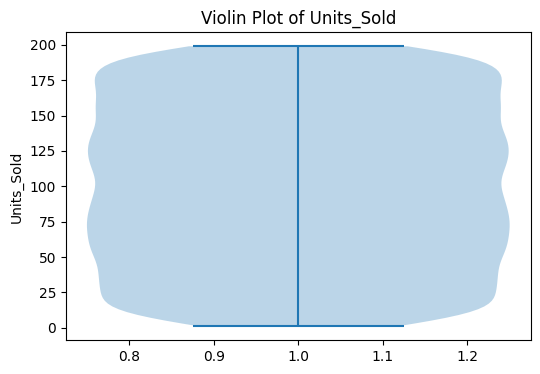

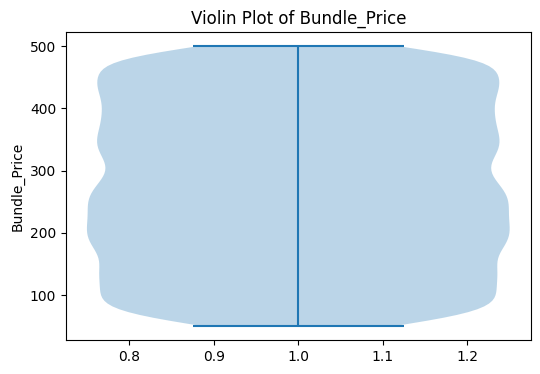

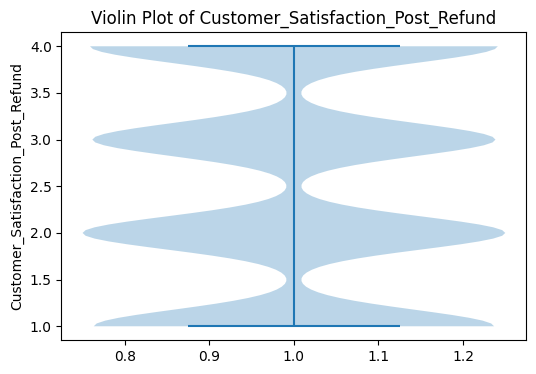

In [36]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.violinplot(marketing_df[col].dropna())
    plt.title(f'Violin Plot of {col}')
    plt.ylabel(col)
    plt.show()

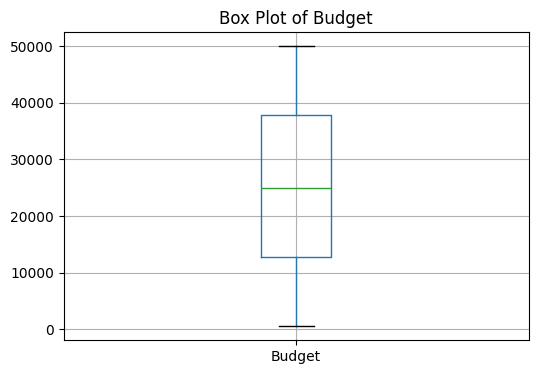

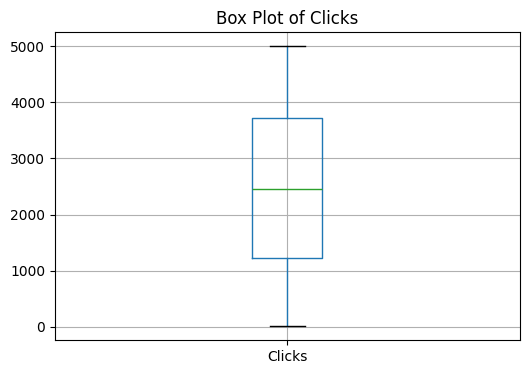

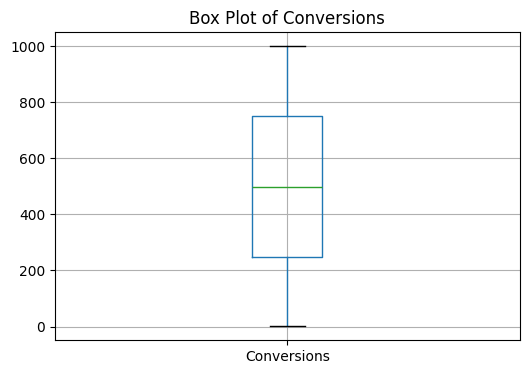

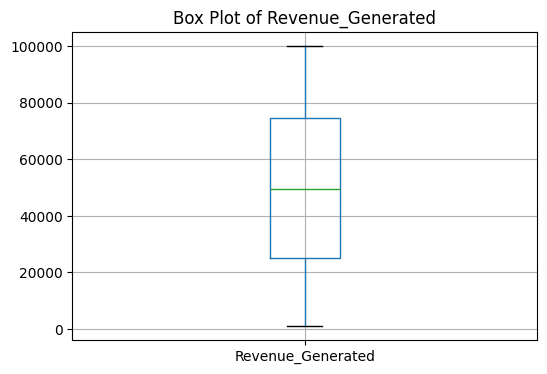

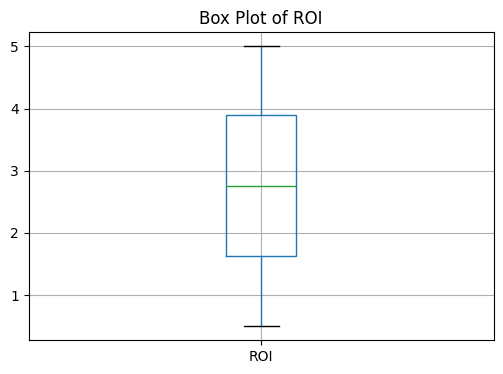

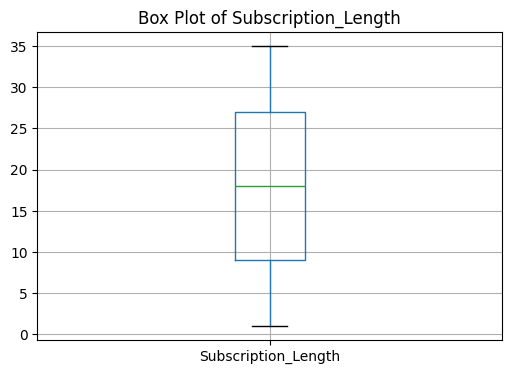

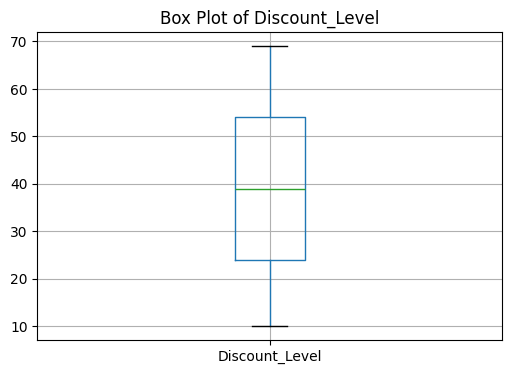

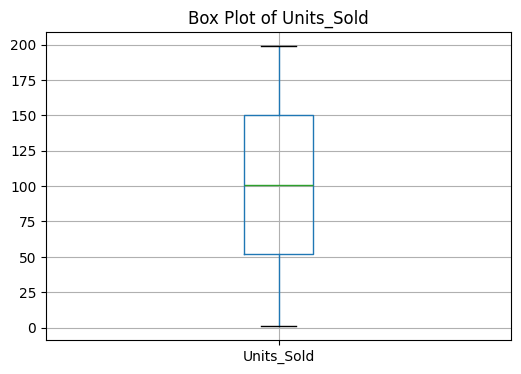

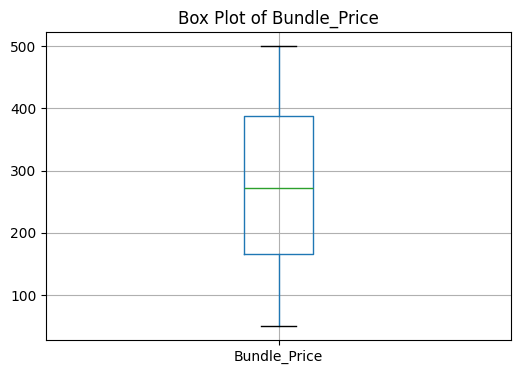

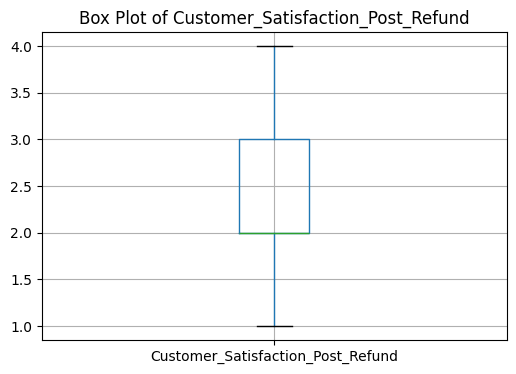

In [30]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    marketing_df.boxplot(column=col)
    plt.title(f'Box Plot of {col}')
    plt.show()

The overall shape of the distribution of each column is very uniform. Per the box plots, there are no outliers in the data, which is surprising. Regarding the number of bins for the histograms, I am finding that no matter what I do the distribution is uniformm. I am unsure if there is an aspect that I am missing when it comes to fine tunig these graphs. Also, I did not find the violin plots to be helpful. 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

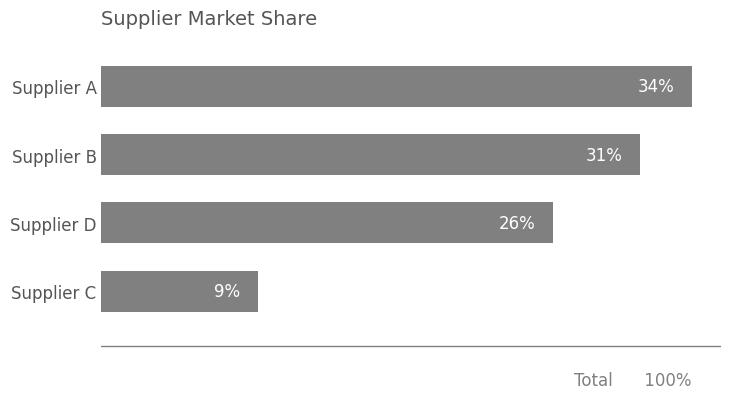

In [5]:
import matplotlib.pyplot as plt

suppliers = ['Supplier C', 'Supplier D', 'Supplier B', 'Supplier A'] 
market_share = [9, 26, 31, 34]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(suppliers, market_share, color='gray', height=0.6)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=12, colors='#555555')

for bar in bars:
    width = bar.get_width()
    ax.text(width - 1, bar.get_y() + bar.get_height()/2, 
            f'{int(width)}%', 
            ha='right', va='center', color='white', fontsize=12)

ax.set_title('Supplier Market Share', loc='left', fontsize=14, color='#555555', pad=20)

plt.axhline(y=-0.8, xmin=0, xmax=1, color='gray', linewidth=1)
ax.text(34, -1.3, 'Total      100%', ha='right', va='center', color='gray', fontsize=12)

plt.show()